# DepositGuard — Risk Scoring & SHAP Explainability

Scores every account with the XGBoost model from `03_model_benchmarking.ipynb`, assigns HIGH/MEDIUM/LOW risk tiers, and uses SHAP to explain what's driving individual predictions.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import shap
from sklearn.tree import DecisionTreeClassifier, export_text
from IPython.display import Markdown, display

plt.style.use('dark_background')

OUTPUT_DIR = "../outputs"
RANDOM_STATE = 42

## Load Feature-Engineered Data and Trained Model

Same `float32` / `int8` / `category` dtype optimization used in the previous notebooks.

In [2]:
categorical_cols = ["payment_type", "employment_status", "housing_status", "source", "device_os"]
int8_cols = ["fraud_bool", "month", "rapid_application", "employment_risk", "email_risk", "credit_tier"]

header_cols = pd.read_csv(f"{OUTPUT_DIR}/featured_data.csv", nrows=0).columns
float32_cols = [c for c in header_cols if c not in categorical_cols and c not in int8_cols]

dtype_map = {col: "category" for col in categorical_cols}
dtype_map.update({col: "int8" for col in int8_cols})
dtype_map.update({col: "float32" for col in float32_cols})

df = pd.read_csv(f"{OUTPUT_DIR}/featured_data.csv", dtype=dtype_map)
xgb_model = joblib.load(f"{OUTPUT_DIR}/xgb_model.pkl")

print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")
print(f"Loaded model: {type(xgb_model).__name__}")

Loaded: 1,000,000 rows x 42 columns
Loaded model: XGBClassifier


## Rebuild the Model's Feature Matrix

Identical one-hot encoding to `03_model_benchmarking.ipynb` (`fraud_bool` and `month` excluded, categorical columns one-hot encoded), then defensively reindexed to the exact column order the saved XGBoost booster expects.

In [3]:
feature_cols = [c for c in df.columns if c not in ["fraud_bool", "month"]]
X = pd.get_dummies(df[feature_cols], columns=categorical_cols, drop_first=True)

booster_features = xgb_model.get_booster().feature_names
X = X.reindex(columns=booster_features, fill_value=0)

print(f"Feature matrix: {X.shape[0]:,} rows x {X.shape[1]} columns (matches model: {list(X.columns) == booster_features})")

Feature matrix: 1,000,000 rows x 56 columns (matches model: True)


## 1. Score All 1M Accounts

In [4]:
df["fraud_probability"] = xgb_model.predict_proba(X)[:, 1]
df["fraud_probability"].describe()

count    1000000.000000
mean           0.068397
std            0.123420
min            0.000070
25%            0.007996
50%            0.021995
75%            0.065775
max            0.990689
Name: fraud_probability, dtype: float64

## 2-3. Data-Driven Threshold Discovery

A shallow `DecisionTreeClassifier(max_depth=3)` fit on `fraud_probability` alone (predicting the true `fraud_bool` label) reveals where the score naturally separates fraud from legitimate accounts — useful as a sanity check against the fixed business thresholds used below.

In [5]:
threshold_tree = DecisionTreeClassifier(max_depth=3, random_state=RANDOM_STATE)
threshold_tree.fit(df[["fraud_probability"]], df["fraud_bool"])

print(export_text(threshold_tree, feature_names=["fraud_probability"]))

natural_thresholds = sorted(t for t in threshold_tree.tree_.threshold if t != -2.0)
print("Natural threshold splits found by the tree:")
for t in natural_thresholds:
    print(f"  {t:.4f}")

|--- fraud_probability <= 0.48
|   |--- fraud_probability <= 0.19
|   |   |--- fraud_probability <= 0.08
|   |   |   |--- class: 0
|   |   |--- fraud_probability >  0.08
|   |   |   |--- class: 0
|   |--- fraud_probability >  0.19
|   |   |--- fraud_probability <= 0.35
|   |   |   |--- class: 0
|   |   |--- fraud_probability >  0.35
|   |   |   |--- class: 0
|--- fraud_probability >  0.48
|   |--- fraud_probability <= 0.85
|   |   |--- fraud_probability <= 0.69
|   |   |   |--- class: 0
|   |   |--- fraud_probability >  0.69
|   |   |   |--- class: 0
|   |--- fraud_probability >  0.85
|   |   |--- fraud_probability <= 0.92
|   |   |   |--- class: 0
|   |   |--- fraud_probability >  0.92
|   |   |   |--- class: 1

Natural threshold splits found by the tree:
  0.0792
  0.1930
  0.3486
  0.4819
  0.6935
  0.8530
  0.9186


## 4. Assign Risk Tiers

Fixed business thresholds: `HIGH` >= 0.75, `MEDIUM` >= 0.40, else `LOW`. These are used for the actual tier assignment regardless of where the diagnostic tree above happened to split — the tree is exploratory, the cutoffs here are the deliverable.

In [6]:
conditions = [
    df["fraud_probability"] >= 0.75,
    df["fraud_probability"] >= 0.40,
]
choices = ["HIGH", "MEDIUM"]
df["risk_tier"] = np.select(conditions, choices, default="LOW")

## 5. Tier Distribution

In [7]:
tier_counts = df["risk_tier"].value_counts().reindex(["HIGH", "MEDIUM", "LOW"])
tier_pct = (tier_counts / len(df) * 100).round(3)

tier_summary = pd.DataFrame({"count": tier_counts, "percentage": tier_pct})
print(tier_summary.to_string())

            count  percentage
risk_tier                    
HIGH         5411       0.541
MEDIUM      29449       2.945
LOW        965140      96.514


## 6. SHAP Values on a 10,000-Account Sample

Computing SHAP values for all 1M accounts is too slow, so we sample 10,000 accounts from the `month > 5` temporal test period (the same held-out set used for model evaluation in notebook 3) and explain those.

In [8]:
test_idx = X[df["month"] > 5].index
sample_idx = pd.Series(test_idx).sample(n=10_000, random_state=RANDOM_STATE).values
X_sample = X.loc[sample_idx]

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer(X_sample)

print(f"SHAP values shape: {shap_values.values.shape}")

SHAP values shape: (10000, 56)


## 7-8. SHAP Plots

Global feature importance (mean |SHAP value|) and the beeswarm summary plot, both styled for dark mode.

In [9]:
def apply_dark_theme(fig):
    fig.patch.set_facecolor("black")
    for ax in fig.get_axes():
        ax.set_facecolor("black")
        ax.tick_params(colors="white")
        ax.xaxis.label.set_color("white")
        ax.yaxis.label.set_color("white")
        ax.title.set_color("white")
        for spine in ax.spines.values():
            spine.set_color("white")
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_color("white")

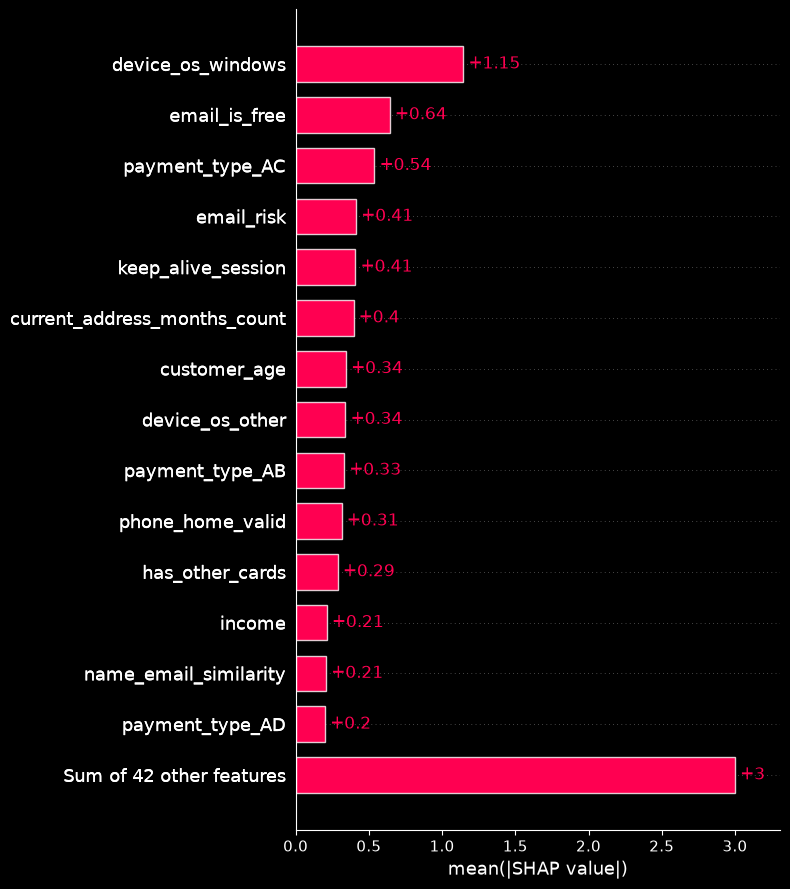

In [10]:
shap.plots.bar(shap_values, max_display=15, show=False)
fig = plt.gcf()
apply_dark_theme(fig)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/feature_importance.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

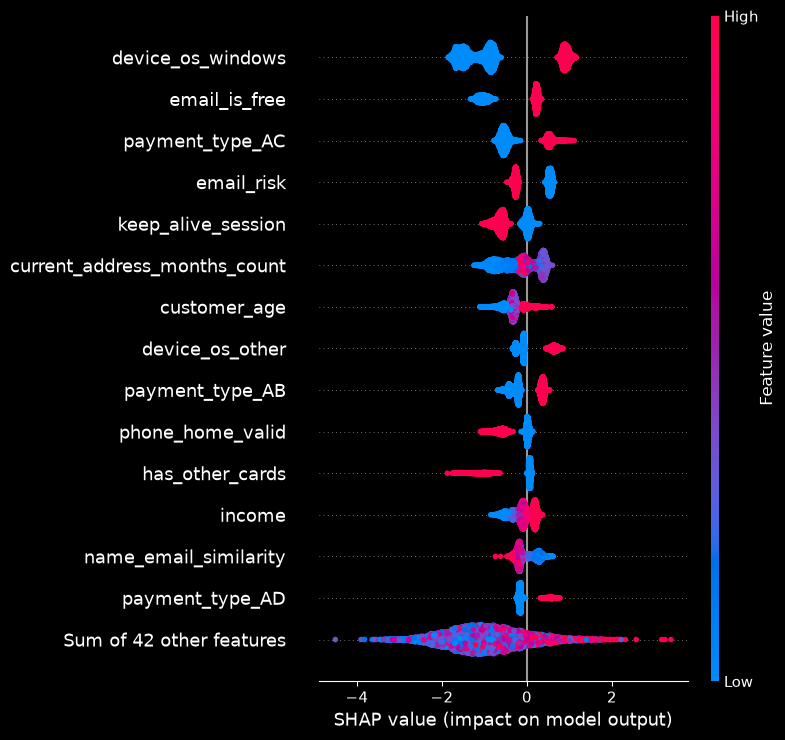

In [11]:
shap.plots.beeswarm(shap_values, max_display=15, show=False)
fig = plt.gcf()
apply_dark_theme(fig)
plt.tight_layout()
plt.savefig(f"{OUTPUT_DIR}/shap_summary.png", dpi=150, facecolor=fig.get_facecolor())
plt.show()

## 9. Top 10 Features by SHAP Importance

In [12]:
mean_abs_shap = np.abs(shap_values.values).mean(axis=0)
feature_importance = pd.Series(mean_abs_shap, index=X_sample.columns).sort_values(ascending=False)

print(feature_importance.head(10).round(4).to_string())

device_os_windows               1.1450
email_is_free                   0.6425
payment_type_AC                 0.5382
email_risk                      0.4127
keep_alive_session              0.4084
current_address_months_count    0.3955
customer_age                    0.3437
device_os_other                 0.3402
payment_type_AB                 0.3312
phone_home_valid                0.3140


## 10. Save Scored Output

For the 10,000-account SHAP sample: `fraud_probability`, `risk_tier`, plus that account's top 5 individual SHAP feature/value pairs (ranked by absolute SHAP value for that specific account, not the global ranking above).

In [13]:
shap_arr = shap_values.values
feature_names = np.array(X_sample.columns)
top5_idx = np.argsort(-np.abs(shap_arr), axis=1)[:, :5]

top5_records = []
for row_i, idxs in enumerate(top5_idx):
    record = {}
    for rank, feat_i in enumerate(idxs, start=1):
        record[f"shap_feature_{rank}"] = feature_names[feat_i]
        record[f"shap_value_{rank}"] = shap_arr[row_i, feat_i]
    top5_records.append(record)

top5_df = pd.DataFrame(top5_records, index=X_sample.index)

scored_accounts = df.loc[X_sample.index, ["fraud_probability", "risk_tier"]].join(top5_df)
scored_accounts.index.name = "account_index"

scored_path = f"{OUTPUT_DIR}/scored_accounts.csv"
scored_accounts.to_csv(scored_path)
print(f"Saved {len(scored_accounts):,} scored accounts to {scored_path}")
scored_accounts.head()

Saved 10,000 scored accounts to ../outputs/scored_accounts.csv


,fraud_probability,risk_tier,shap_feature_1,shap_value_1,shap_feature_2,shap_value_2,shap_feature_3,shap_value_3,shap_feature_4,shap_value_4,shap_feature_5,shap_value_5
account_index,,,,,,,,,,,,
975292,0.138713,LOW,device_os_windows,-0.947008,payment_type_AC,-0.607349,device_distinct_emails_8w,0.516048,current_address_months_count,-0.469498,payment_type_AB,0.363799
858234,0.005214,LOW,device_os_windows,-1.752849,device_os_other,0.714613,current_address_months_count,-0.705477,keep_alive_session,-0.612520,phone_home_valid,-0.582332
924664,0.072536,LOW,device_os_windows,-1.035558,payment_type_AC,-0.655336,payment_type_AD,0.500643,payment_type_AB,-0.394092,customer_age,-0.322700
909580,0.005105,LOW,device_os_windows,-0.830283,customer_age,-0.738906,current_address_months_count,-0.717817,payment_type_AC,-0.571605,address_stability,-0.522810
795798,0.003403,LOW,device_os_windows,-1.608342,has_other_cards,-0.941136,email_is_free,-0.882283,device_os_other,0.786603,phone_home_valid,-0.607500


## 11. Sample HIGH Risk Accounts

In [14]:
high_risk = scored_accounts[scored_accounts["risk_tier"] == "HIGH"]
n_show = min(5, len(high_risk))
print(f"{len(high_risk):,} HIGH risk accounts in the 10,000-account SHAP sample; showing {n_show}.\n")

if n_show == 0:
    print("No HIGH risk accounts found in this SHAP sample.")
else:
    for account_idx, row in high_risk.sample(n=n_show, random_state=RANDOM_STATE).iterrows():
        print(f"Account {account_idx} — fraud_probability = {row['fraud_probability']:.4f}")
        for rank in range(1, 6):
            print(f"    {rank}. {row[f'shap_feature_{rank}']:<35s} {row[f'shap_value_{rank}']:+.4f}")
        print()

59 HIGH risk accounts in the 10,000-account SHAP sample; showing 5.

Account 951580 — fraud_probability = 0.9497
    1. device_os_windows                   +0.9794
    2. proposed_credit_limit               +0.9757
    3. email_is_free                       -0.9404
    4. payment_type_AC                     +0.5052
    5. credit_risk_score                   +0.5015

Account 943674 — fraud_probability = 0.8308
    1. device_os_windows                   +1.0781
    2. payment_type_AC                     +0.6189
    3. credit_risk_score                   +0.5523
    4. current_address_months_count        +0.3859
    5. customer_age                        -0.3072

Account 963727 — fraud_probability = 0.8518
    1. device_os_windows                   +1.0969
    2. proposed_credit_limit               +0.9859
    3. credit_risk_score                   +0.7114
    4. payment_type_AC                     -0.5620
    5. payment_type_AB                     +0.3833

Account 830181 — fraud_probabil